# Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the structure, distribution, and key characteristics of the sales dataset before conducting detailed business analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("SampleSuperstore.csv",encoding="latin1")

In [14]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [15]:
df["Year"] = df["Order Date"].dt.year
df["Quarter"] = df["Order Date"].dt.quarter
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.month_name()

In [16]:
df[["Order Date", "Year", "Quarter", "Month", "Month Name"]].head()

,Order Date,Year,Quarter,Month,Month Name
0,2016-11-08,2016,4,11,November
1,2016-11-08,2016,4,11,November
2,2016-06-12,2016,2,6,June
3,2015-10-11,2015,4,10,October
4,2015-10-11,2015,4,10,October


In [3]:
df.shape

(9994, 21)

In [4]:
df["Order ID"].nunique()

5009

In [5]:
df["Customer ID"].nunique()

793

In [6]:
df["Product ID"].nunique()

1862

In [7]:
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Quantity:", df["Quantity"].sum())
print("Total Orders:", df["Order ID"].nunique())
print("Total Customers:", df["Customer ID"].nunique())
print("Total Products:", df["Product ID"].nunique())

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Quantity: 37873
Total Orders: 5009
Total Customers: 793
Total Products: 1862


In [8]:
df[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


# Monthly Sales Trend Analysis

In [17]:
monthly_sales = (
    df.groupby(["Year", "Month"])["Sales"]
    .sum()
    .reset_index()
)

monthly_sales

,Year,Month,Sales
0,2014,1,14236.8950
1,2014,2,4519.8920
2,2014,3,55691.0090
3,2014,4,28295.3450
4,2014,5,23648.2870
5,2014,6,34595.1276
6,2014,7,33946.3930
7,2014,8,27909.4685
8,2014,9,81777.3508
9,2014,10,31453.3930


In [19]:
monthly_sales["Month Name"] = pd.to_datetime(
    monthly_sales["Month"], 
    format="%m"
).dt.month_name()

monthly_sales.head(15)

,Year,Month,Sales,Month Name
0,2014,1,14236.8950,January
1,2014,2,4519.8920,February
2,2014,3,55691.0090,March
3,2014,4,28295.3450,April
4,2014,5,23648.2870,May
5,2014,6,34595.1276,June
6,2014,7,33946.3930,July
7,2014,8,27909.4685,August
8,2014,9,81777.3508,September
9,2014,10,31453.3930,October


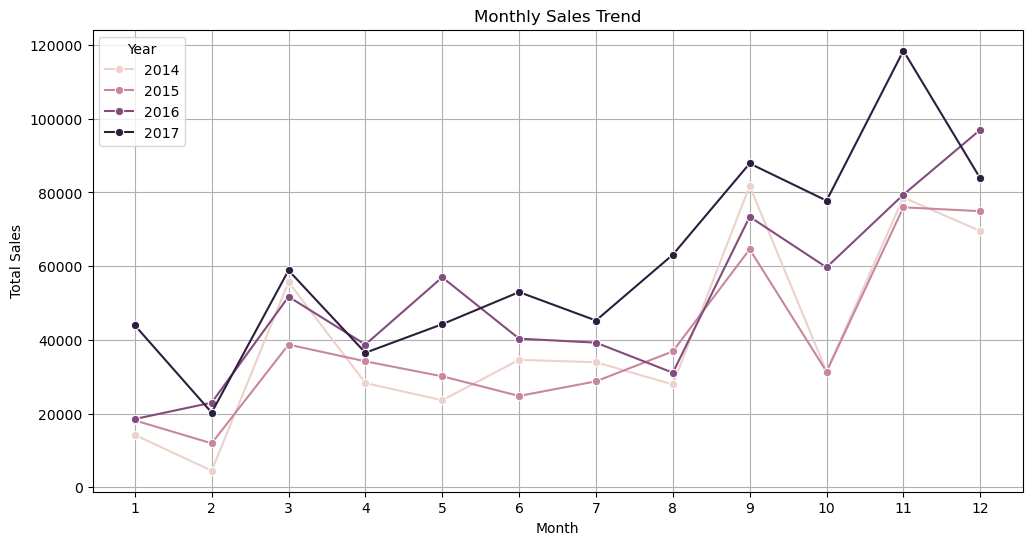

In [20]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

# Monthly Sales Observation

- Sales performance varies significantly across months and years.
- The highest monthly sales were observed in November 2017.
- The lowest monthly sales were observed in February 2014.
- Sales generally show stronger performance during the later months of the year.
- The 2017 sales trend shows comparatively stronger performance than the previous years.

# Quarterly Sales Trend Analysis

This analysis evaluates sales performance across different quarters to identify the best and lowest-performing quarterly periods.

In [21]:
quarterly_sales = (
    df.groupby(["Year", "Quarter"])["Sales"]
    .sum()
    .reset_index()
)

quarterly_sales

,Year,Quarter,Sales
0,2014,1,74447.7960
1,2014,2,86538.7596
2,2014,3,143633.2123
3,2014,4,179627.7302
4,2015,1,68851.7386
5,2015,2,89124.1870
6,2015,3,130259.5752
7,2015,4,182297.0082
8,2016,1,93237.1810
9,2016,2,136082.3010


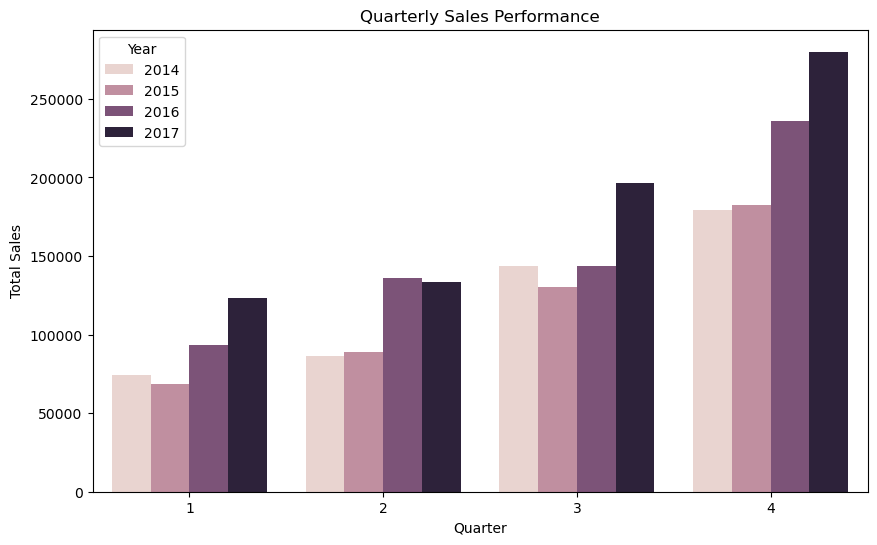

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=quarterly_sales,
    x="Quarter",
    y="Sales",
    hue="Year"
)

plt.title("Quarterly Sales Performance")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.show()

# Quarterly Sales 

- Q4 recorded the strongest overall sales performance across the analyzed years.
- The highest quarterly sales were recorded in Q4 2017.
- The lowest quarterly sales were recorded in Q1 2014.
- Sales performance generally shows stronger results in the later quarters, particularly Q4.
- The year 2017 demonstrates comparatively stronger quarterly sales performance than the previous years.

# Yearly Sales Trend Analysis

This analysis evaluates annual sales performance to understand overall business growth across different years. Yearly Sales Trend Analysis

This analysis evaluates annual sales performance to understand overall business growth across different years.



In [23]:
yearly_sales = (
    df.groupby("Year")["Sales"]
    .sum()
    .reset_index()
)

yearly_sales

,Year,Sales
0,2014,484247.4981
1,2015,470532.5090
2,2016,609205.5980
3,2017,733215.2552


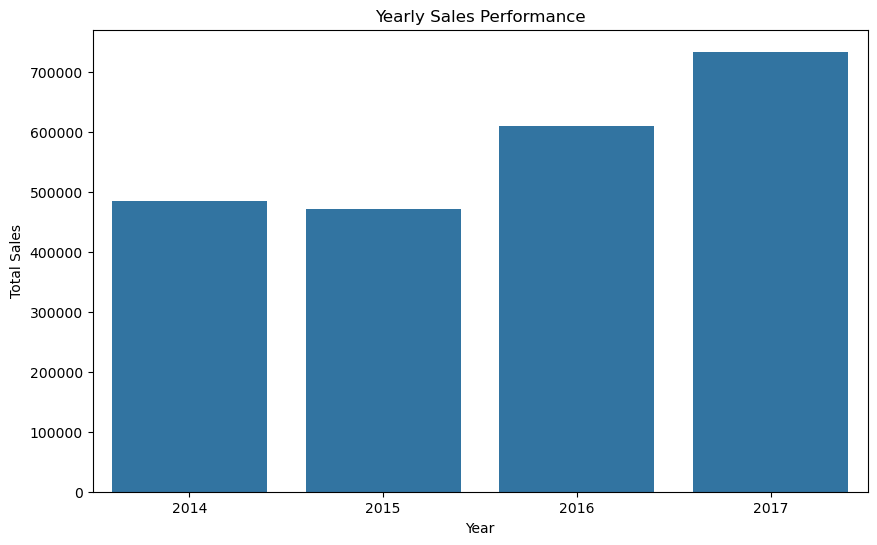

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=yearly_sales,
    x="Year",
    y="Sales"
)

plt.title("Yearly Sales Performance")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

# Yearly Sales 

- 2017 recorded the highest annual sales among all analyzed years.
- 2015 recorded the lowest annual sales.
- Sales declined slightly from 2014 to 2015.
- Sales showed strong growth from 2015 onwards.
- The overall yearly trend indicates an improvement in sales performance over time.

# Top-Selling Products Analysis

This analysis identifies the products that generate the highest sales revenue.

In [25]:
product_sales = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

product_sales.head(10)

,Product Name,Sales
0,Canon imageCLASS 2200 Advanced Copier,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,21870.576
4,GBC DocuBind TL300 Electric Binding System,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
6,Hewlett Packard LaserJet 3310 Copier,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
8,GBC DocuBind P400 Electric Binding System,17965.068
9,High Speed Automatic Electric Letter Opener,17030.312


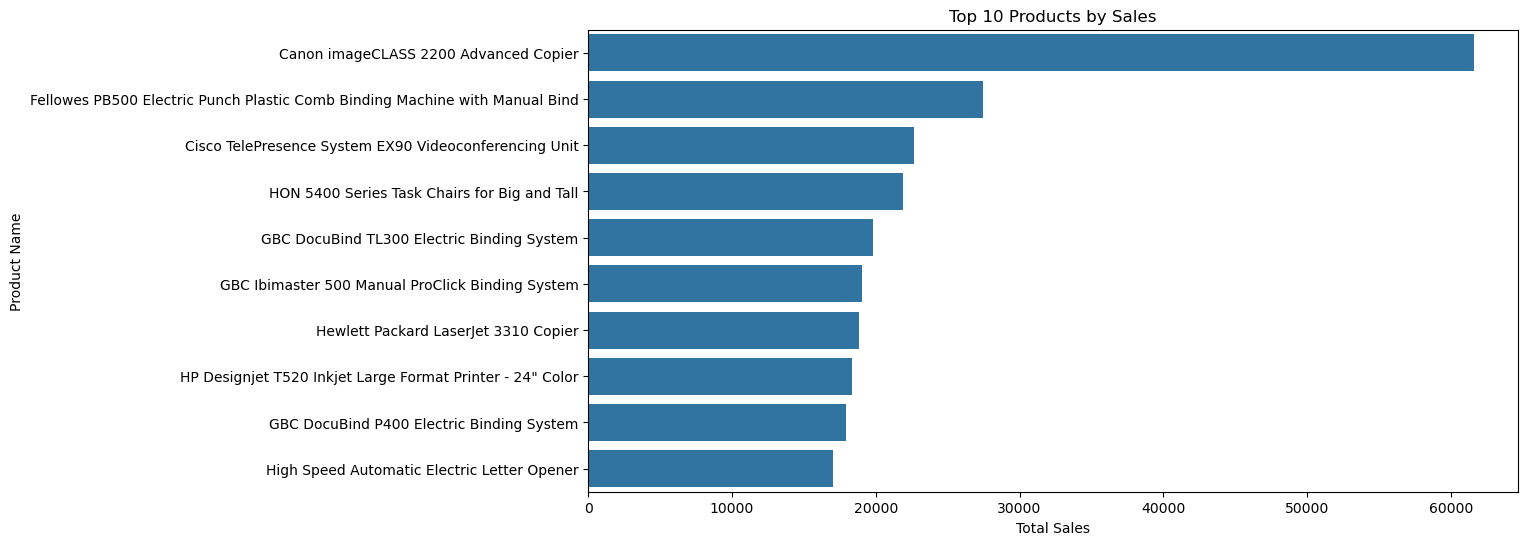

In [26]:
top_10_products = product_sales.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_products,
    x="Sales",
    y="Product Name"
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.show()

# Top-Selling Products 

- Canon imageCLASS 2200 Advanced Copier generated the highest sales among the top 10 products.
- Fellowes PB500 Electric Punch Plastic Comb Binding Machine ranked second in terms of sales.
- Cisco TelePresence System EX90 Videoconferencing Unit ranked third.
- The top-selling products are predominantly high-value office technology and equipment products.
- The leading product shows a significant sales contribution compared with the other top-performing products.

# Low-Performing Items Analysis

This analysis identifies the products with the lowest sales performance.

In [27]:
low_performing_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=True)
    .reset_index()
)

low_performing_products.head(10)

,Product Name,Sales
0,Eureka Disposable Bags for Sanitaire Vibra Gro...,1.624
1,Avery 5,5.760
2,Xerox 20,6.480
3,Grip Seal Envelopes,7.072
4,Avery Hi-Liter Pen Style Six-Color Fluorescent...,7.700
5,Avery Hi-Liter Comfort Grip Fluorescent Highli...,7.800
6,Xerox 1989,7.968
7,4009 Highlighters,8.040
8,Stockwell Gold Paper Clips,8.096
9,Newell 308,8.400


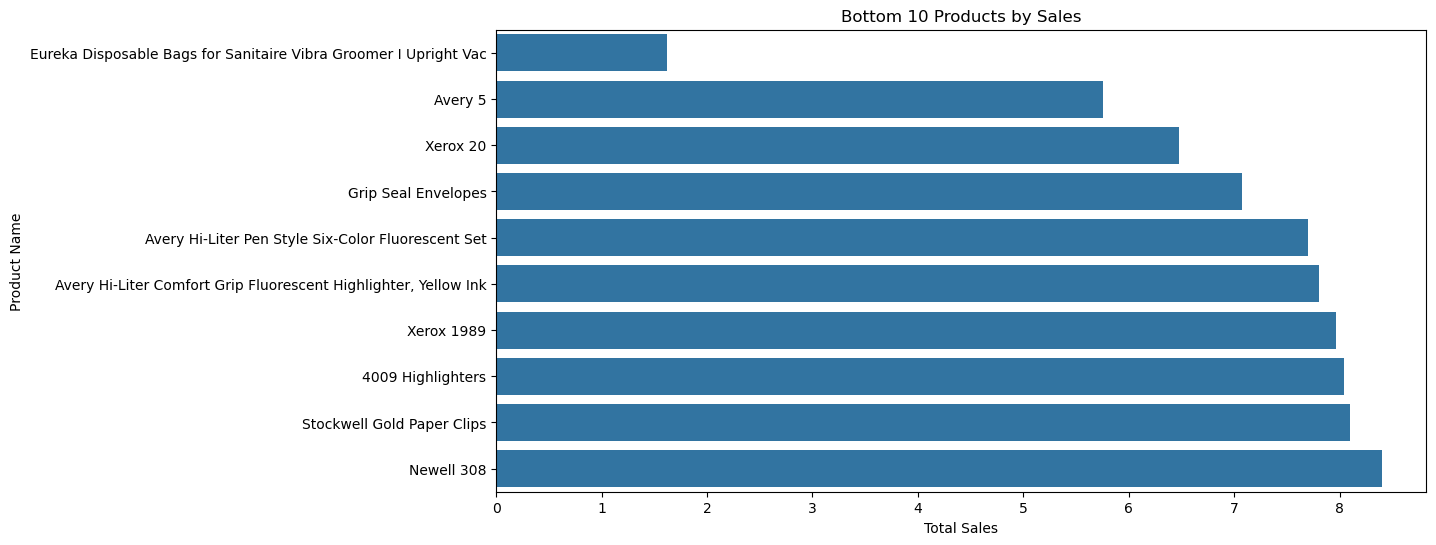

In [28]:
bottom_10_products = low_performing_products.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=bottom_10_products,
    x="Sales",
    y="Product Name"
)

plt.title("Bottom 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.show()

# Low-Performing Items 

- Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac recorded the lowest sales among the analyzed products.
- Avery 5 and Xerox 20 were also among the lowest-selling products.
- Newell 308 had the highest sales within the bottom 10 products, while still remaining in the low-performing group.
- The identified low-performing products may require further business review to understand their low sales performance.

# Region-wise Sales Comparison

In [29]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

region_sales

,Region,Sales
0,West,725457.8245
1,East,678781.2400
2,Central,501239.8908
3,South,391721.9050


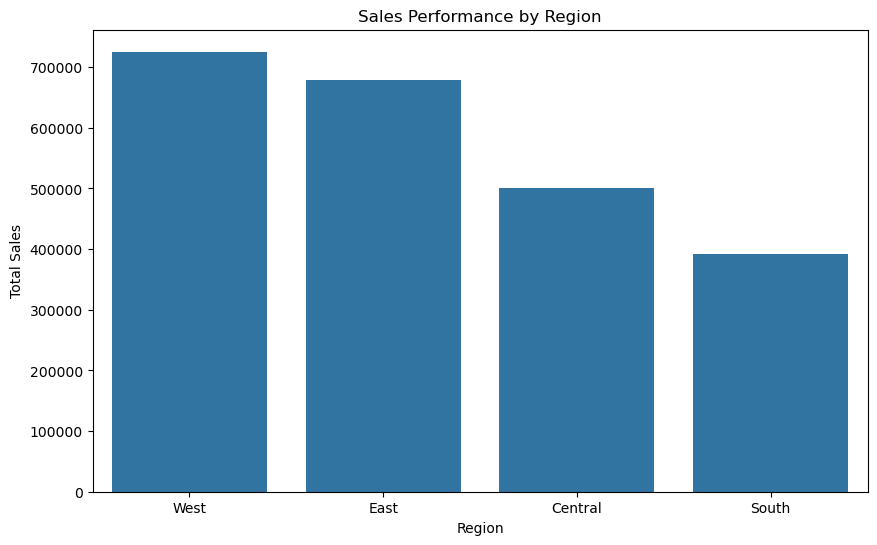

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_sales,
    x="Region",
    y="Sales"
)

plt.title("Sales Performance by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

# Region-wise Sales Comparison

- The West region recorded the highest sales performance.
- The East region ranked second in terms of total sales.
- The Central region recorded lower sales compared with West and East.
- The South region recorded the lowest sales among all regions.
- The significant difference in regional sales indicates opportunities to improve performance in lower-performing regions.

# Category-wise Sales Comparison

In [31]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_sales

,Category,Sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


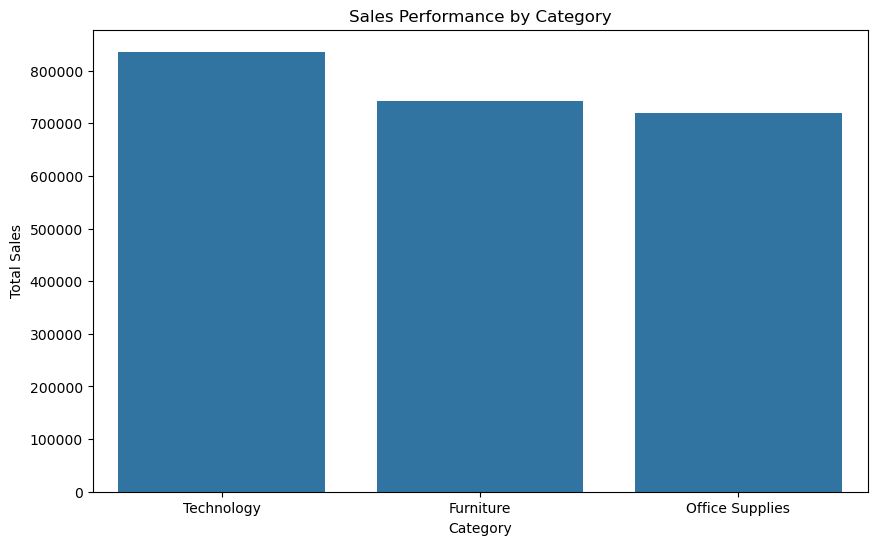

In [32]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_sales,
    x="Category",
    y="Sales"
)

plt.title("Sales Performance by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

# Category-wise Sales Comparison 

- Technology recorded the highest sales among all categories.
- Furniture ranked second in terms of total sales.
- Office Supplies recorded the lowest sales among the three categories.
- Technology showed a noticeable lead over Furniture and Office Supplies.
- The sales performance across the three categories is relatively strong, although Technology is the clear top-performing category.

# Key Performance Indicators (KPIs)

This section calculates the key performance indicators required to evaluate overall sales performance, profitability, and business growth.

In [33]:
total_revenue = df["Sales"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 2297200.8603


In [34]:
total_profit = df["Profit"].sum()

print("Total Profit:", total_profit)

Total Profit: 286397.0217


In [38]:
yearly_sales["Growth Rate (%)"] = (
    yearly_sales["Sales"].pct_change() * 100
)

yearly_sales

,Year,Sales,Growth Rate (%)
0,2014,484247.4981,NaN
1,2015,470532.5090,-2.832227
2,2016,609205.5980,29.471521
3,2017,733215.2552,20.355962


In [36]:
yearly_sales["Growth Rate (%)"] = yearly_sales["Growth Rate (%)"].round(2)

yearly_sales

,Year,Sales,Growth Rate (%)
0,2014,484247.4981,NaN
1,2015,470532.5090,-2.83
2,2016,609205.5980,29.47
3,2017,733215.2552,20.36


In [37]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Profit"
    ],
    "Value": [
        total_revenue,
        total_profit
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,2.297201e+06
1,Total Profit,2.863970e+05


In [39]:
yearly_sales

,Year,Sales,Growth Rate (%)
0,2014,484247.4981,NaN
1,2015,470532.5090,-2.832227
2,2016,609205.5980,29.471521
3,2017,733215.2552,20.355962


# KPI Observations

- The total revenue generated during the analyzed period was $2,297,200.86.
  
- The total profit generated during the analyzed period was $286,397.02.

  
- Sales declined by 2.83% in 2015 compared with 2014.

  
- Sales increased significantly by 29.47% in 2016.

  
- Sales continued to grow by 20.36% in 2017.

  
- Overall, the business demonstrated strong sales growth after 2015.